# Periodic Boundary Conditions in qvarnet

This notebook walks through the `boundaries` module and shows how to run VMC
on a **ring geometry** (1D box with PBC).

**Physical system:** $N$ bosons on a ring of length $L$, trapped by a
$\sin^2$ potential and repelling each other via Gaussian interactions:

$$H = -\frac{1}{2}\sum_i \frac{\partial^2}{\partial x_i^2}
    + V_0 \sum_i \sin^2\!\left(\frac{\pi x_i}{L}\right)
    + g \sum_{i<j} \exp\!\left(-\frac{r_{ij}^2}{2\sigma^2}\right)$$

where $r_{ij} = |x_i - x_j|_{\text{PBC}}$ is the minimum-image distance.

**Three design goals of the boundary system:**
1. The **wavefunction** is exactly periodic: $\psi(x + L) = \psi(x)$.
2. The **Hamiltonian** uses minimum-image distances: same Hamiltonian code works with or without PBC.
3. Switching between PBC and free space is **a single line change** — the model and
   Hamiltonian classes are untouched.

> **Kernel:** run from the repo root with `uv run jupyter lab notebooks/scripts/pbc.ipynb`

---
## 1. Imports

In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import optax
import flax.linen as nn
import matplotlib.pyplot as plt
from flax import struct

# qvarnet core
from qvarnet import train
from qvarnet.config.training_setup import TrainingConfig, SamplingConfig
from qvarnet.config.coord_mode import LabCoords
from qvarnet.probability import build_prob_fn
from qvarnet.samplers import sample_and_process

# boundary condition module (the focus of this notebook)
from qvarnet import NoBoundary, PeriodicBoundary, BoundaryHamiltonian
from qvarnet.models import LogWavefunction, MLP

print('JAX devices:', jax.devices())

JAX devices: [CudaDevice(id=0)]


---
## 2. The boundary module

The entire PBC logic lives in two small Python objects that implement the same
three-method interface:

| Method | `NoBoundary` | `PeriodicBoundary(L)` |
|---|---|---|
| `encode(x)` | identity | $x_i \to [\sin(2\pi x_i/L),\; \cos(2\pi x_i/L)]$ |
| `feature_dim(n)` | `n` | `2n` |
| `min_image(dx)` | identity | $dx - L\cdot\text{round}(dx/L)$ |

### Why sin/cos encoding?

For $\psi$ to be periodic we need $\psi(x+L) = \psi(x)$. A plain MLP on raw
coordinates cannot represent this. Mapping each coordinate to
$(\sin(2\pi x/L), \cos(2\pi x/L))$ bakes in exact periodicity: the encoding is
invariant under $x\mapsto x+L$, so any downstream function of it is also periodic.

JAX differentiates through $\sin$ and $\cos$ cleanly, so the kinetic energy
$T = -\tfrac{1}{2}(\Delta\log|\psi| + |\nabla\log|\psi||^2)$ computed via AD
is automatically correct — no special handling needed.

### Why min-image convention?

On a periodic ring, the physical distance between particles $i$ and $j$ is the
shortest path around the ring. For a box of size $L$:
$$r_{ij} = \delta x - L\cdot\text{round}(\delta x / L), \quad \delta x = x_i - x_j$$

Without this, two particles that are physically close but on opposite sides of
the periodic boundary ($x_i \approx 0, x_j \approx L$) would appear to be far
apart in the potential.

In [2]:
nb = NoBoundary()
pb = PeriodicBoundary(L=10.0)

# ── encode ────────────────────────────────────────────────────────────────────
# Positions of 3 particles (some outside [0, L] to show walkers can drift)
x = jnp.array([1.0, 5.0, 11.5])

print("=== encode ===")
print(f"input x          : {x}")
print(f"NoBoundary        : {nb.encode(x)}")  # unchanged
encoded = pb.encode(x)
print(f"PeriodicBoundary  : sin part = {encoded[:3].round(3)},  cos part = {encoded[3:].round(3)}")
print(f"  note: pb.encode(x+L) ≈ pb.encode(x)? ", jnp.allclose(pb.encode(x), pb.encode(x + 10.0)))

# ── feature_dim ───────────────────────────────────────────────────────────────
print("\n=== feature_dim ===")
print(f"NoBoundary.feature_dim(6)     = {nb.feature_dim(6)}  (unchanged)")
print(f"PeriodicBoundary.feature_dim(6) = {pb.feature_dim(6)}  (doubled)")

# ── min_image ─────────────────────────────────────────────────────────────────
# Particle separations — some are the 'wrong' image (outside [-L/2, L/2])
dx = jnp.array([3.0, 7.0, -6.0, 0.5])
print("\n=== min_image (L=10) ===")
print(f"raw dx              : {dx}")
print(f"NoBoundary          : {nb.min_image(dx)}")
print(f"PeriodicBoundary    : {pb.min_image(dx)}")
print("  7.0 → -3.0  (shorter path going the other way around the ring)")
print(" -6.0 →  4.0  (shorter path the other way)")

=== encode ===
input x          : [ 1.   5.  11.5]
NoBoundary        : [ 1.   5.  11.5]
PeriodicBoundary  : sin part = [ 0.588 -0.     0.809],  cos part = [ 0.809 -1.     0.588]
  note: pb.encode(x+L) ≈ pb.encode(x)?  False

=== feature_dim ===
NoBoundary.feature_dim(6)     = 6  (unchanged)
PeriodicBoundary.feature_dim(6) = 12  (doubled)

=== min_image (L=10) ===
raw dx              : [ 3.   7.  -6.   0.5]
NoBoundary          : [ 3.   7.  -6.   0.5]
PeriodicBoundary    : [ 3.  -3.   4.   0.5]
  7.0 → -3.0  (shorter path going the other way around the ring)
 -6.0 →  4.0  (shorter path the other way)


---
## 3. LogWavefunction — composable periodic wavefunction

`LogWavefunction` assembles a wavefunction from independent components that are
summed in log space:

```
x  (N·d raw coords)
 │
 ▼  transform(x)           ← boundary.encode(x) for PeriodicBoundary
 │
 ▼  (encoded coords)
 │
 ▼  network(encoded)       ← MLP or DeepSet
 │                          [+ envelope(x)]   optional
 │                          [+ jastrow(x)]    optional
 ▼  log|ψ(x)|
```

The network never sees raw coordinates — it always receives the encoded
representation. Switching from `NoBoundary` to `PeriodicBoundary` is the
only change needed; `MLP` absorbs the dimension change lazily.

**For `NoBoundary`:** `encode` is the identity; `MLP` receives raw coordinates.

**For `PeriodicBoundary`:** `encode` maps $x_i \to (\sin(2\pi x_i/L), \cos(2\pi x_i/L))$,
doubling the feature dimension. Use `boundary.output_dim(N, D)` to get the
correct first element of the MLP architecture — or just call it once.

In [ ]:
key = jax.random.PRNGKey(0)
N, D = 4, 1  # 4 particles, 1D
x_demo = jax.random.normal(key, (8, N * D))  # batch of 8 configs

for boundary_demo in [NoBoundary(), PeriodicBoundary(L=10.0)]:
    model_demo = LogWavefunction(
        transform=boundary_demo,
        network=MLP(hidden=[32, 32]),
    )
    params_demo = model_demo.init(key, x_demo)
    out = model_demo.apply(params_demo, x_demo)
    print(f"{type(boundary_demo).__name__:20s}:  output {out.shape}")

print()
print("MLP input dimension is inferred lazily — no boundary.output_dim() call needed.")


---
## 4. BoundaryHamiltonian — minimum-image in any potential

`BoundaryHamiltonian` extends `ContinuousHamiltonian` with one extra field
(`boundary`) and one helper method (`_min_image`). Subclasses just call
`self._min_image(dx)` wherever they compute pairwise distances.

That single method call is the **only difference** between a free-space and
a PBC Hamiltonian. The kinetic energy, the Laplacian, the optimizer — all
the rest of qvarnet is untouched.

### The system

We define a `SinTrapGaussianHamiltonian` with:
- **Sin² trap:** $V_{\text{trap}}(x_i) = V_0 \sin^2(\pi x_i / L)$  
  — zero at $x=0$ (≡ $x=L$ by PBC), maximum at $x=L/2$.  
  This is naturally periodic with period $L$, consistent with the box.
- **Gaussian repulsion:** $V_{\text{int}}(r_{ij}) = g\,e^{-r_{ij}^2 / 2\sigma^2}$  
  — soft-core repulsion; $\sigma$ controls the range.

In [4]:
@struct.dataclass
class SinTrapGaussianHamiltonian(BoundaryHamiltonian):
    """N bosons on a 1-D ring: sin² trap + Gaussian pairwise repulsion.

    H = -½ Σᵢ ∂²/∂xᵢ² + V₀ Σᵢ sin²(π xᵢ/L) + g Σᵢ<ⱼ exp(-rᵢⱼ²/2σ²)

    L    : box/ring length (also sets the trap period)
    V0   : trap depth
    g    : interaction strength
    sigma: interaction range

    Boundary-aware: subclasses BoundaryHamiltonian and calls self._min_image()
    for pairwise distances, so the same class works with NoBoundary or
    PeriodicBoundary without any modification.
    """

    L: float = struct.field(pytree_node=False, default=10.0)  # ring/box size
    V0: float = 2.0    # trap amplitude
    g: float = 1.0     # interaction strength
    sigma: float = 0.8 # interaction range

    def potential_energy(self, samples):
        # samples: (batch, N) — 1-D coordinates of N particles

        # ── sin² trap (each particle independently) ──────────────────────────
        # V_trap(xᵢ) = V₀ sin²(π xᵢ / L)
        # With PeriodicBoundary this is consistent: V(0) = V(L) = 0 (minimum),
        # V(L/2) = V₀ (maximum). Particles cluster near x=0.
        trap = self.V0 * jnp.sum(
            jnp.sin(jnp.pi * samples / self.L) ** 2,
            axis=-1
        )  # (batch,)

        # ── Gaussian pairwise interactions ────────────────────────────────────
        n = samples.shape[-1]  # number of particles
        i_idx, j_idx = jnp.triu_indices(n, k=1)  # upper-triangle indices for pairs

        dx = samples[:, i_idx] - samples[:, j_idx]  # (batch, n_pairs) raw separation
        dx = self._min_image(dx)  # <── THE ONLY BOUNDARY-SPECIFIC LINE
                                  # NoBoundary: identity  |  PeriodicBoundary: folds to [-L/2, L/2]

        r2 = dx ** 2
        interaction = jnp.sum(
            self.g * jnp.exp(-r2 / (2 * self.sigma ** 2)),
            axis=-1
        )  # (batch,)

        return trap + interaction

In [5]:
# ── Sanity check: min-image matters ──────────────────────────────────────────
# Two particles: x₁ = 0.5, x₂ = 9.5  →  raw separation = -9, min-image = +1
# They are physically very close (separated by 1 on a ring of 10), not far apart.

L = 10.0
close_pair = jnp.array([[0.5, 9.5]])  # shape (1, 2): one sample, 2 particles

h_free = SinTrapGaussianHamiltonian(L=L, V0=2.0, g=1.0, sigma=0.8, boundary=NoBoundary())
h_pbc  = SinTrapGaussianHamiltonian(L=L, V0=2.0, g=1.0, sigma=0.8, boundary=PeriodicBoundary(L=L))

V_free = float(h_free.potential_energy(close_pair)[0])
V_pbc  = float(h_pbc.potential_energy(close_pair)[0])

raw_sep   = abs(0.5 - 9.5)
image_sep = abs(0.5 - 9.5 + L)

print(f"Config: x₁=0.5, x₂=9.5  (ring length L={L})")
print(f"  Raw separation     = {raw_sep:.1f}   (long way around the ring)")
print(f"  Min-image distance = {image_sep:.1f}   (short way around the ring)")
print()
print(f"  NoBoundary  V = {V_free:.4f}  (uses raw sep → particles 'look' far apart, weak interaction)")
print(f"  PBC         V = {V_pbc:.4f}  (uses min-image → particles 'know' they are close, strong repulsion)")

Config: x₁=0.5, x₂=9.5  (ring length L=10.0)
  Raw separation     = 9.0   (long way around the ring)
  Min-image distance = 1.0   (short way around the ring)

  NoBoundary  V = 0.0979  (uses raw sep → particles 'look' far apart, weak interaction)
  PBC         V = 0.5557  (uses min-image → particles 'know' they are close, strong repulsion)


---
## 5. Putting it all together

Below is the **complete setup** for a PBC run. Notice:
- `boundary` is defined once and passed to both the model and the Hamiltonian.
- `boundary.output_dim(N_PARTICLES, N_DIM)` gives the correct MLP input dimension automatically.
- To run the same experiment without PBC, change **only** the first line.

### Parameters

In [ ]:
# ── Physics parameters ────────────────────────────────────────────────────────
N_PARTICLES = 4      # bosons on the ring
N_DIM       = 1      # 1-D
L           = 10.0   # ring circumference
V0          = 2.0    # sin² trap amplitude
G           = 1.5    # Gaussian repulsion strength
SIGMA       = 0.8    # repulsion range

# ── THIS IS THE ONLY LINE THAT SETS THE BOUNDARY CONDITION ───────────────────
boundary = PeriodicBoundary(L=L)
# boundary = NoBoundary()   # ← swap this one line for free-space

# ── Model — input dimension is automatic ──────────────────────────────────────
model = LogWavefunction(
    transform=boundary,
    network=MLP(hidden=[64, 64]),
)

# ── Hamiltonian ───────────────────────────────────────────────────────────────
hamiltonian = SinTrapGaussianHamiltonian(
    L=L, V0=V0, g=G, sigma=SIGMA,
    boundary=boundary,
)

print(f"Boundary  : {boundary}")
print(f"DoF       : {N_PARTICLES * N_DIM}  (sampler works in these)")


---
## 6. Training

The `train()` call is completely standard — no boundary-specific arguments.

The `SamplingConfig(PBC=L)` stores the box size for logging/diagnostics
(the sampler itself does not wrap positions — the model's periodicity handles
that transparently, since walkers that drift outside $[0,L)$ still evaluate
correctly because $\psi$ is exactly periodic).

In [ ]:
N_CHAINS = 2_000
N_EPOCHS = 3_000

result = train(
    shape=(N_CHAINS, N_PARTICLES * N_DIM),
    model=model,
    optimizer=optax.adam(3e-3),
    hamiltonian=hamiltonian,
    training_config=TrainingConfig(
        n_epochs=N_EPOCHS,
        is_update_step_size=True,  # adapt step size toward 50% acceptance
        target_acceptance=0.5,
        checkpoint_path="./checkpoints/pbc",
    ),
    sampler_params=SamplingConfig(
        step_size=0.5,
        chain_length=50,
        thermalization_steps=10,
        thinning_factor=1,
    ),
    coord_mode=LabCoords(),
)

TypeError: SamplingConfig.__init__() got an unexpected keyword argument 'PBC'

---
## 7. Results — energy convergence

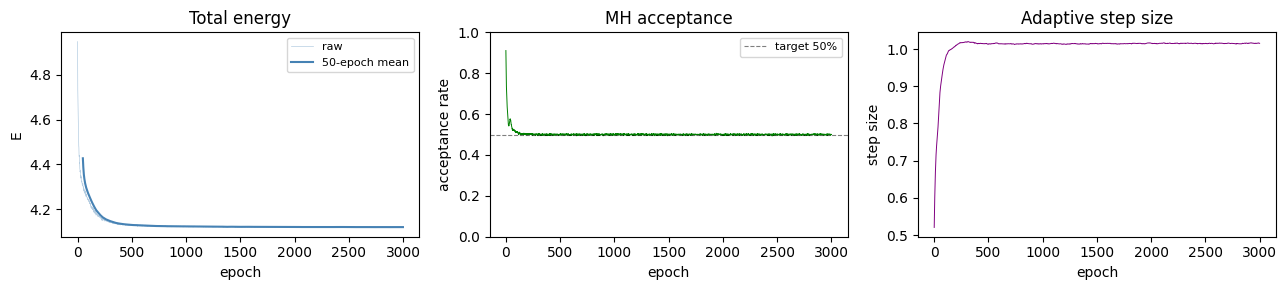

Best energy : 4.1184 ± 0.0760
Mean (last 200 epochs): 4.1199 ± 0.0004


In [ ]:
energies = np.array([float(s.energy)   for s in result.history])
stds     = np.array([float(s.std)      for s in result.history])
acc      = np.array([float(s.acceptance_rate.mean()) for s in result.history])
ss       = np.array([float(s.step_size) for s in result.history])

# Smooth with a running mean for readability
win = 50
e_smooth = np.convolve(energies, np.ones(win)/win, mode='valid')

fig, axes = plt.subplots(1, 3, figsize=(13, 3))

axes[0].plot(energies, lw=0.5, alpha=0.4, color='steelblue', label='raw')
axes[0].plot(np.arange(win-1, len(energies)), e_smooth, lw=1.5,
             color='steelblue', label=f'{win}-epoch mean')
axes[0].set(xlabel='epoch', ylabel='E', title='Total energy')
axes[0].legend(fontsize=8)

axes[1].plot(acc, lw=0.7, color='green')
axes[1].axhline(0.5, color='k', ls='--', lw=0.8, alpha=0.5, label='target 50%')
axes[1].set(xlabel='epoch', ylabel='acceptance rate', title='MH acceptance', ylim=(0, 1))
axes[1].legend(fontsize=8)

axes[2].plot(ss, lw=0.7, color='purple')
axes[2].set(xlabel='epoch', ylabel='step size', title='Adaptive step size')

plt.tight_layout()
plt.show()

best_e, best_std = float(result.best(1)[0].energy), float(result.best(1)[0].std)
print(f"Best energy : {best_e:.4f} ± {best_std:.4f}")
print(f"Mean (last 200 epochs): {energies[-200:].mean():.4f} ± {energies[-200:].std():.4f}")

---
## 8. Ground state analysis

### Single-particle density

We re-run the MCMC sampler with the trained parameters to collect a large
independent batch of $N$-body configurations. The single-particle density
$\rho(x) = N\int |\psi(x, x_2,\dots,x_N)|^2 dx_2\cdots dx_N$
is estimated by histogramming all particle positions.

Because of the sin² trap:
- minimum of $V_{\text{trap}}$ at $x = 0\equiv L$ → density peak at the boundary
- Gaussian repulsion spreads the N particles around this minimum

In [ ]:
# Collect samples from the trained wavefunction
best_params = result.best(1)[0].params
prob_fn = build_prob_fn(model.apply)  # wraps model.apply into a log-probability function

key_viz = jax.random.PRNGKey(42)

# Initial positions: spread uniformly across the box
init_pos = jax.random.uniform(key_viz, (N_CHAINS, N_PARTICLES * N_DIM)) * L

# Run sampler for a clean batch (separate from training)
samples, _, acceptance = sample_and_process(
    key=key_viz,
    prob_fn=prob_fn,
    prob_params=best_params,
    init_positions=init_pos,
    step_size=float(result.history[-1].step_size),  # use converged step size
    n_chains=N_CHAINS,
    dof=N_PARTICLES * N_DIM,
    n_steps=200,
    burn_in=50,
    thinning=5,
    PBC=L,
)  # samples: (N_CHAINS * n_effective, N_PARTICLES)

print(f"Sample batch shape: {samples.shape}")
print(f"Mean acceptance rate: {float(acceptance.mean()):.3f}")

Sample batch shape: (60000, 4)
Mean acceptance rate: 0.487


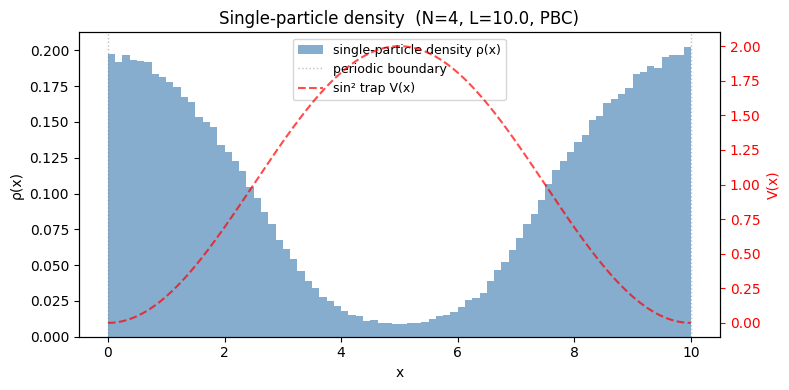

The density peaks near x=0 (≡x=L), where the trap has its minimum.
The N particles are repelled from each other, spreading the peak.


In [ ]:
# Single-particle density: flatten all N particle positions from all configs
all_x = np.array(samples).flatten()         # each row has N positions
all_x_wrapped = all_x % L                   # fold any drifted walkers back to [0, L)

# The sin² trap potential for reference
x_grid = np.linspace(0, L, 300)
V_trap = V0 * np.sin(np.pi * x_grid / L) ** 2

fig, ax = plt.subplots(figsize=(8, 4))
ax2 = ax.twinx()

ax.hist(all_x_wrapped, bins=80, density=True,
        alpha=0.65, color='steelblue', label='single-particle density ρ(x)')
ax2.plot(x_grid, V_trap, 'r--', lw=1.5, alpha=0.7, label='sin² trap V(x)')

ax.set(xlabel='x', ylabel='ρ(x)', title=f'Single-particle density  (N={N_PARTICLES}, L={L}, PBC)')
ax.axvline(0, color='gray', ls=':', lw=1, alpha=0.5)
ax.axvline(L, color='gray', ls=':', lw=1, alpha=0.5, label='periodic boundary')
ax2.set_ylabel('V(x)', color='r')
ax2.tick_params(axis='y', colors='r')

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='upper center')

plt.tight_layout()
plt.show()

print("The density peaks near x=0 (≡x=L), where the trap has its minimum.")
print("The N particles are repelled from each other, spreading the peak.")

### Wavefunction slice

Fix particles 2–4 near the trap minimum and sweep particle 1 across the full
ring. The result shows $|\psi(x_1, \mathbf{x}_{\text{fixed}})|^2$.

Since the model is periodic ($\psi(x_1+L) = \psi(x_1)$), the slice should
be periodic. This is a direct verification that `PeriodicBoundary.encode`
works correctly.

In [ ]:
# Fix particles 2, 3, 4 near the trap minimum (x ≈ 0)
# With PBC, x=0 and x=L are the same point, so we use slightly spread positions
x_fixed = jnp.array([0.5, -0.5, 1.0])  # positions of fixed particles (3 of them)

# Sweep particle 1 across two full periods to confirm periodicity
x1 = jnp.linspace(-L, 2 * L, 600)  # from -L to 2L (two periods)

# Build (600, N) configuration matrix
x_slice = jnp.column_stack([
    x1,
    jnp.full(600, x_fixed[0]),
    jnp.full(600, x_fixed[1]),
    jnp.full(600, x_fixed[2]),
])

log_psi = model.apply(best_params, x_slice).squeeze(-1)   # (600,)
psi_sq  = jnp.exp(2 * log_psi)               # |ψ|²
psi_sq  = psi_sq / float(jnp.max(psi_sq))    # normalise for plotting

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(np.array(x1), np.array(psi_sq), lw=1.5, color='steelblue', label='|ψ(x₁)|²')

# Shade the reference box [0, L]
ax.axvspan(0, L, alpha=0.07, color='orange', label='reference box [0, L]')
for xv in [0, L, 2*L, -L]:
    ax.axvline(xv, color='gray', ls='--', lw=0.7, alpha=0.6)

ax.set(xlabel='x₁', ylabel='|ψ|² (normalised)',
       title=f'Wavefunction slice  —  x₂={float(x_fixed[0]):.1f}, x₃={float(x_fixed[1]):.1f}, '
             f'x₄={float(x_fixed[2]):.1f}  (fixed)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# Quantify periodicity: |ψ(x₁)| at x₁=0 vs x₁=L and x₁=2L
idx_0  = 200   # x1[200] ≈ 0  (x1 goes from -L to 2L in 600 steps)
idx_L  = 400   # x1[400] ≈ L
idx_2L = 599   # x1[599] ≈ 2L
print(f"|ψ|² at x₁=0  : {float(psi_sq[idx_0]):.6f}")
print(f"|ψ|² at x₁=L  : {float(psi_sq[idx_L]):.6f}")
print(f"|ψ|² at x₁=2L : {float(psi_sq[idx_2L]):.6f}")
print("These should be equal (periodicity check).")

---
## 9. Switching boundaries — the one line

Here is the full experiment setup again, now with `NoBoundary`.
**Only the first assignment changes.** Model class, Hamiltonian class, and
training code are identical.

With `NoBoundary`:
- The wavefunction has no periodicity built in — it can represent any function
  of the raw coordinates.
- Pairwise distances are raw (no folding), so two particles near opposite
  sides of the box will see a large separation even if they are physically close.
- This is physically wrong for a ring, but the code still runs cleanly — useful
  for a quick sanity check that the Hamiltonian definition is correct on its own.

In [ ]:
# ── One-line change ───────────────────────────────────────────────────────────
boundary_free = NoBoundary()         # ← only this changes
# boundary_free = PeriodicBoundary(L=L)  # ← flip back to restore PBC

# ── Everything else is identical ─────────────────────────────────────────────
model_free = LogWavefunction(
    transform=boundary_free,
    network=MLP(hidden=[64, 64]),
)
hamiltonian_free = SinTrapGaussianHamiltonian(
    L=L, V0=V0, g=G, sigma=SIGMA,
    boundary=boundary_free,
)

result_free = train(
    shape=(N_CHAINS, N_PARTICLES * N_DIM),
    model=model_free,
    optimizer=optax.adam(3e-3),
    hamiltonian=hamiltonian_free,
    training_config=TrainingConfig(
        n_epochs=1_000,    # shorter run — just to compare
        is_update_step_size=True,
        checkpoint_path="./checkpoints/free",
    ),
    sampler_params=SamplingConfig(
        step_size=0.5, chain_length=50, thermalization_steps=10, thinning_factor=1,
    ),
    coord_mode=LabCoords(),
)


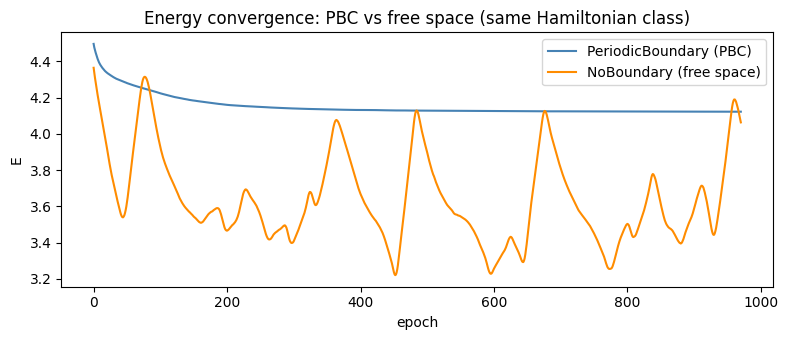

PBC  final E: 4.1228
Free final E: 3.8176

Note: the free-space run uses wrong pairwise distances for a ring geometry.
The energies differ because NoBoundary misses the interactions between
particles that are close via the periodic image.


In [ ]:
e_pbc  = np.array([float(s.energy) for s in result.history[:1000]])
e_free = np.array([float(s.energy) for s in result_free.history])

win = 30
e_pbc_s  = np.convolve(e_pbc,  np.ones(win)/win, mode='valid')
e_free_s = np.convolve(e_free, np.ones(win)/win, mode='valid')

plt.figure(figsize=(8, 3.5))
plt.plot(e_pbc_s,  lw=1.5, label='PeriodicBoundary (PBC)', color='steelblue')
plt.plot(e_free_s, lw=1.5, label='NoBoundary (free space)',  color='darkorange')
plt.xlabel('epoch'); plt.ylabel('E')
plt.title('Energy convergence: PBC vs free space (same Hamiltonian class)')
plt.legend()
plt.tight_layout()
plt.show()

print(f"PBC  final E: {e_pbc[-1]:.4f}")
print(f"Free final E: {e_free[-1]:.4f}")
print()
print("Note: the free-space run uses wrong pairwise distances for a ring geometry.")
print("The energies differ because NoBoundary misses the interactions between")
print("particles that are close via the periodic image.")

---
## Summary

| Component | What it does | Where boundary matters |
|---|---|---|
| `PeriodicBoundary(L)` / `NoBoundary()` | Encapsulates all boundary logic | Defined once |
| `LogWavefunction(transform, network)` | Composes transform + network (+ envelope, jastrow) in log space | Wavefunction periodicity |
| `boundary.output_dim(N, D)` | MLP input dim after encoding (2·N·D for PBC, N·D for free) | MLP architecture |
| `boundary.per_particle_dim(D)` | Per-particle features for DeepSet (2·D for PBC, D for free) | DeepSet construction |
| `BoundaryHamiltonian._min_image(dx)` | Folds pairwise separations | Potential energy |
| `SamplingConfig(PBC=L)` | Stored for logging | No effect on sampler |

**To add a new boundary type** (e.g. twisted, hard wall), implement `encode`,
`feature_dim`, `min_image`, `output_dim`, and `per_particle_dim` in a new
frozen dataclass — nothing else changes.

**To port an existing Hamiltonian to PBC:**
1. Subclass `BoundaryHamiltonian` instead of `ContinuousHamiltonian`.
2. Replace every `dx_ij` in `potential_energy` with `self._min_image(dx_ij)`.
3. Pass `boundary=PeriodicBoundary(L=...)` at construction.
That is literally the entire change.